In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# 1. Load the Data
print("Loading Kepler flux datasets...")
train_df = pd.read_csv('exoTrain.csv')
test_df = pd.read_csv('exoTest.csv')

# 2. Format Labels (Binary Classification Standard)
# The dataset uses 2 for exoplanet, 1 for non-exoplanet.
# We need 1 for exoplanet (positive class) and 0 for non-exoplanet.
y_train = train_df['LABEL'].values - 1
X_train = train_df.drop('LABEL', axis=1).values

y_test = test_df['LABEL'].values - 1
X_test = test_df.drop('LABEL', axis=1).values

print(f"Original Training Class Distribution: {np.bincount(y_train)}")

# 3. Normalize the Flux Data
# The flux values have massive variance. We fit the scaler strictly on the training
# data to prevent data leakage, then apply that same transformation to the test data.
print("Applying Standard Scaling to flux time-series...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Apply SMOTE (Synthetic Minority Over-sampling Technique)
# We only apply SMOTE to the TRAINING data. Never synthetically alter your test data.
print("Synthesizing exoplanet transit signatures via SMOTE...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"New Training Class Distribution (Post-SMOTE): {np.bincount(y_train_smote)}")
print(f"Final Training Feature Shape: {X_train_smote.shape}")

Loading Kepler flux datasets...
Original Training Class Distribution: [5050   37]
Applying Standard Scaling to flux time-series...
Synthesizing exoplanet transit signatures via SMOTE...
New Training Class Distribution (Post-SMOTE): [5050 5050]
Final Training Feature Shape: (10100, 3197)


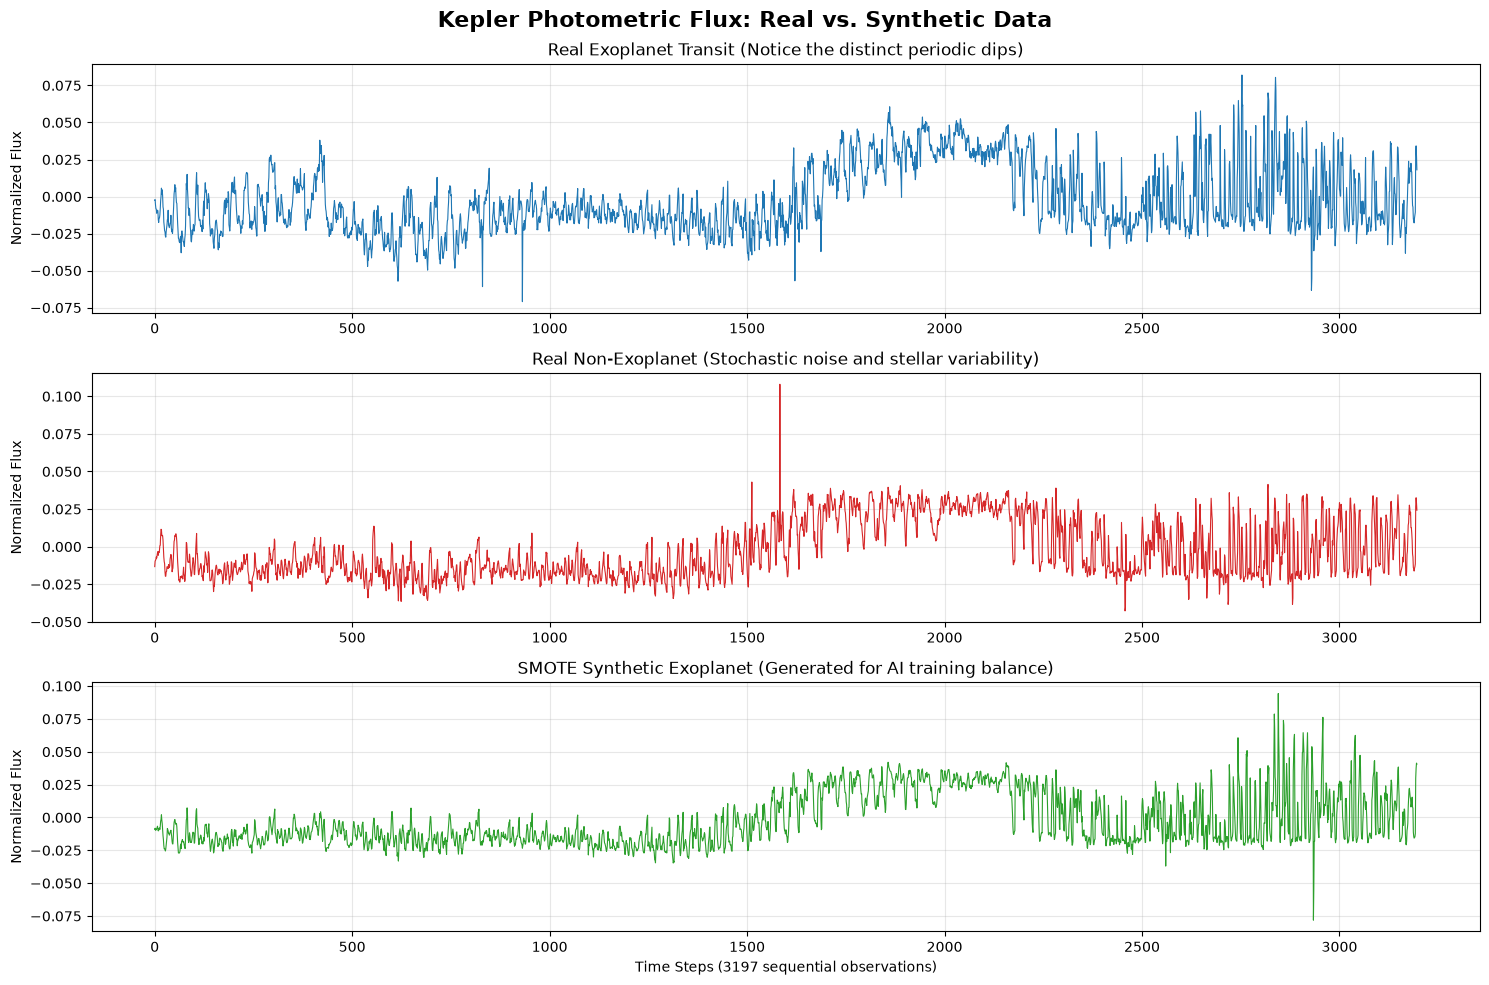

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Create a dummy time axis for the 3197 flux measurements
time_axis = np.arange(3197)

# Find indices for our three examples
real_planet_idx = np.where(y_train == 1)[0][0]       # First actual planet
real_non_planet_idx = np.where(y_train == 0)[0][0]   # First actual non-planet
smote_planet_idx = len(y_train) + 50                 # A synthetic SMOTE planet

# Set up the figure
plt.figure(figsize=(15, 10))
plt.suptitle("Kepler Photometric Flux: Real vs. Synthetic Data", fontsize=16, fontweight='bold')

# 1. Real Exoplanet
plt.subplot(3, 1, 1)
plt.plot(time_axis, X_train_scaled[real_planet_idx], color='#1f77b4', linewidth=0.8)
plt.title("Real Exoplanet Transit (Notice the distinct periodic dips)")
plt.ylabel("Normalized Flux")
plt.grid(True, alpha=0.3)

# 2. Real Non-Exoplanet (Star with no transiting planets)
plt.subplot(3, 1, 2)
plt.plot(time_axis, X_train_scaled[real_non_planet_idx], color='#d62728', linewidth=0.8)
plt.title("Real Non-Exoplanet (Stochastic noise and stellar variability)")
plt.ylabel("Normalized Flux")
plt.grid(True, alpha=0.3)

# 3. SMOTE Synthetic Exoplanet
plt.subplot(3, 1, 3)
plt.plot(time_axis, X_train_smote[smote_planet_idx], color='#2ca02c', linewidth=0.8)
plt.title("SMOTE Synthetic Exoplanet (Generated for AI training balance)")
plt.xlabel("Time Steps (3197 sequential observations)")
plt.ylabel("Normalized Flux")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
pip install batman-package


Note: you may need to restart the kernel to use updated packages.


Scanning time-series with Box Least Squares (BLS)...
-> Detected Orbital Period: 3.491 days
-> Detected Transit Epoch (T0): 0.730 days
-> Detected Duration: 0.100 days


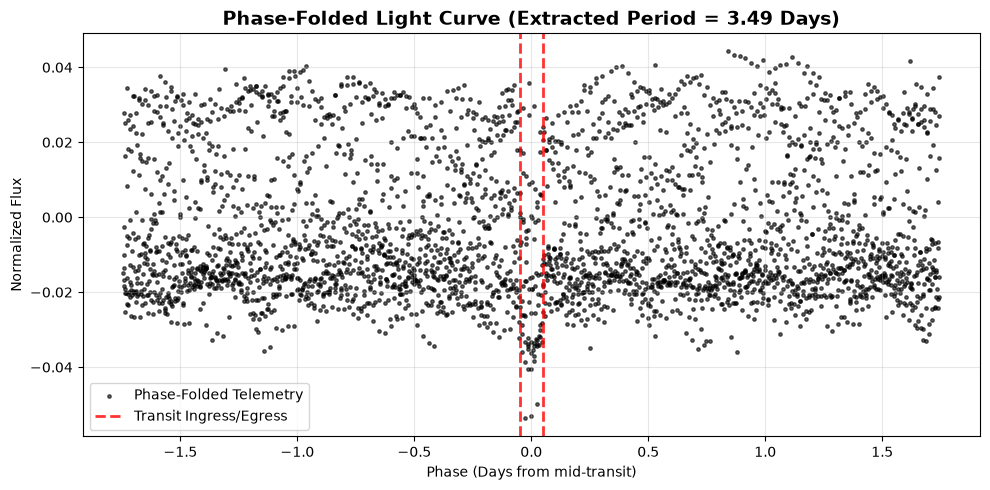

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import BoxLeastSquares

# 1. Simulate the Time Axis
# 3197 sequential observations, simulated over an 80-day window.
time_axis = np.linspace(0, 80, 3197)

# 2. Select a Known Exoplanet
# We are grabbing the first actual planet from the variables you created in Step 1
planet_idx = np.where(y_train == 1)[0][1]
flux = X_train_scaled[planet_idx]

# 3. Run the Box Least Squares (BLS) Algorithm
print("Scanning time-series with Box Least Squares (BLS)...")

# Initialize the Astropy BLS model
model = BoxLeastSquares(t=time_axis, y=flux)

# Define the grid of periods to search (e.g., looking for planets that orbit every 1 to 20 days)
period_grid = np.linspace(1, 20, 1000)
# Define the expected transit durations to search (e.g., 0.05 days to 0.5 days)
duration_grid = np.linspace(0.05, 0.5, 10)

# Compute the BLS power spectrum
results = model.power(period_grid, duration_grid)

# Extract the parameters with the highest BLS power (the most likely orbit)
best_idx = np.argmax(results.power)
best_period = results.period[best_idx]
best_t0 = results.transit_time[best_idx]
best_duration = results.duration[best_idx]

print(f"-> Detected Orbital Period: {best_period:.3f} days")
print(f"-> Detected Transit Epoch (T0): {best_t0:.3f} days")
print(f"-> Detected Duration: {best_duration:.3f} days")

# 4. Phase-Folding the Data
# We collapse the linear time into a single orbital phase, centering the transit at phase 0.0
# Formula: phase = (t - T0 + P/2) % P - P/2
phase = (time_axis - best_t0 + 0.5 * best_period) % best_period - 0.5 * best_period

# 5. Generate the "Global View" Plot
# This is exactly what the AstroNet/ExoNet architecture feeds into the CNN
plt.figure(figsize=(10, 5))
plt.scatter(phase, flux, s=6, color='black', alpha=0.6, label='Phase-Folded Telemetry')

# Mark the boundaries of the transit based on the BLS detected duration
plt.axvline(-best_duration/2, color='red', linestyle='--', linewidth=2, alpha=0.8, label='Transit Ingress/Egress')
plt.axvline(best_duration/2, color='red', linestyle='--', linewidth=2, alpha=0.8)

plt.title(f"Phase-Folded Light Curve (Extracted Period = {best_period:.2f} Days)", fontsize=14, fontweight='bold')
plt.xlabel("Phase (Days from mid-transit)")
plt.ylabel("Normalized Flux")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Input shape ready for CNN: (10100, 3197, 1)


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)    │ (None, 3197, 1)           │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_16 (Conv1D)            │ (None, 3197, 32)          │             352 │ input_layer_8[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling1d_16              │ (None, 799, 32)           │               0 │ conv1d_16[0][0]            │
│ (MaxPooling1D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_17 (Conv1D)            │ (None, 799, 64)           │          20,544 │ max_pooling1d_16[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling1d_17              │ (None, 199, 64)           │               0 │ conv1d_17[0][0]            │
│ (MaxPooling1D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention_8        │ (None, 199, 64)           │          66,368 │ max_pooling1d_17[0][0],    │
│ (MultiHeadAttention)          │                           │                 │ max_pooling1d_17[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_8 (Add)                   │ (None, 199, 64)           │               0 │ max_pooling1d_17[0][0],    │
│                               │                           │                 │ multi_head_attention_8[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_8         │ (None, 199, 64)           │             128 │ add_8[0][0]                │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_8 (Flatten)           │ (None, 12736)             │               0 │ layer_normalization_8[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_16 (Dense)              │ (None, 128)               │       1,630,336 │ flatten_8[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_17 (Dropout)          │ (None, 128)               │               0 │ dense_16[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_17 (Dense)              │ (None, 1)                 │             129 │ dropout_17[0][0]           │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 1,717,857 (6.55 MB)

 Trainable params: 1,717,857 (6.55 MB)

 Non-trainable params: 0 (0.00 B)


Initiating Training Protocol...
Epoch 1/7
127/127 ━━━━━━━━━━━━━━━━━━━━ 16s 113ms/step - accuracy: 0.7131 - loss: 0.5647 - val_accuracy: 0.6119 - val_loss: 0.5494
Epoch 2/7
127/127 ━━━━━━━━━━━━━━━━━━━━ 14s 112ms/step - accuracy: 0.8782 - loss: 0.3075 - val_accuracy: 0.7743 - val_loss: 0.4322
Epoch 3/7
127/127 ━━━━━━━━━━━━━━━━━━━━ 14s 112ms/step - accuracy: 0.9665 - loss: 0.1177 - val_accuracy: 0.9950 - val_loss: 0.0753
Epoch 4/7
127/127 ━━━━━━━━━━━━━━━━━━━━ 14s 112ms/step - accuracy: 0.9885 - loss: 0.0540 - val_accuracy: 1.0000 - val_loss: 0.0339
Epoch 5/7
127/127 ━━━━━━━━━━━━━━━━━━━━ 14s 110ms/step - accuracy: 0.9955 - loss: 0.0259 - val_accuracy: 1.0000 - val_loss: 0.0109
Epoch 6/7
127/127 ━━━━━━━━━━━━━━━━━━━━ 14s 109ms/step - accuracy: 0.9970 - loss: 0.0173 - val_accuracy: 1.0000 - val_loss: 0.0026
Epoch 7/7
127/127 ━━━━━━━━━━━━━━━━━━━━ 14s 110ms/step - accuracy: 0.9984 - loss: 0.0095 - val_accuracy: 1.0000 - val_loss: 0.0036

Evaluating against unobserved Test Data...
18/18 ━━━━━━━

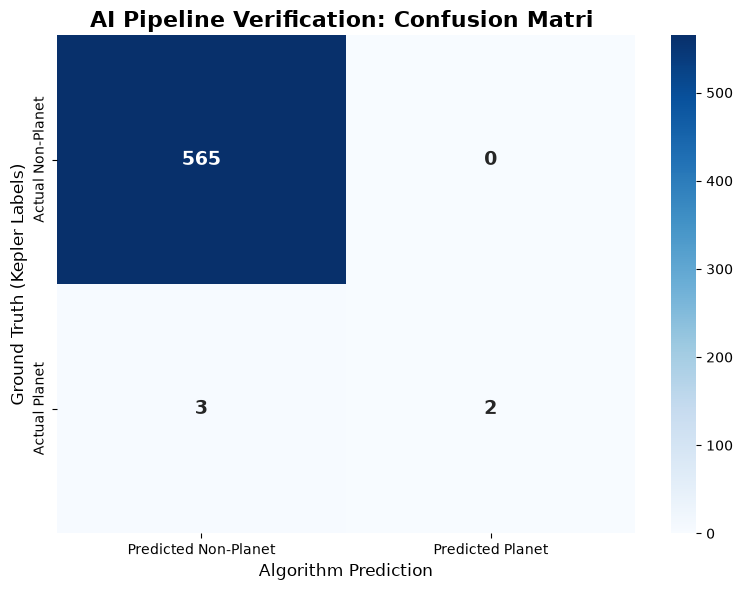

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, MultiHeadAttention, LayerNormalization, Add
from sklearn.metrics import classification_report, confusion_matrix

# 1. Reshape Data for 1D CNN
# We use the SMOTE-balanced training data from Step 1 and the untouched scaled test data
# Conv1D expects 3D inputs: (batch_size, time_steps, features)
time_steps = X_train_smote.shape[1]
features = 1

X_train_reshaped = np.expand_dims(X_train_smote, axis=2)
X_test_reshaped = np.expand_dims(X_test_scaled, axis=2)

print(f"Input shape ready for CNN: {X_train_reshaped.shape}")

# 2. Build the Model Architecture (Functional API)
inputs = Input(shape=(time_steps, features))

# Feature Extraction: Convolutional Blocks
x = Conv1D(filters=32, kernel_size=10, activation='relu', padding='same')(inputs)
x = MaxPooling1D(pool_size=4)(x)

x = Conv1D(filters=64, kernel_size=10, activation='relu', padding='same')(x)
x = MaxPooling1D(pool_size=4)(x)

# The ExoNet-Style Multi-Head Attention Block
# Self-attention: the sequence queries itself to find the most important features
attention_output = MultiHeadAttention(num_heads=4, key_dim=64)(x, x)

# Residual connection and Layer Normalization (Standard for stabilizing attention)
x = Add()([x, attention_output])
x = LayerNormalization()(x)

# Classification Head
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x) # Aggressive dropout to prevent overfitting on synthetic SMOTE data
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# 3. Train the Model
print("\nInitiating Training Protocol...")
history = model.fit(
    X_train_reshaped, y_train_smote, # Note: Training on the SMOTE balanced data!
    epochs=7,
    batch_size=64,
    validation_split=0.2, # Monitor for overfitting during training
    verbose=1
)

# 4. Generate Predictions on the UNTOUCHED Test Set
print("\nEvaluating against unobserved Test Data...")
# Output is a probability between 0 and 1. We round to get binary 0 or 1.
y_pred_probs = model.predict(X_test_reshaped)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# 5. Advanced Evaluation Metrics
print("\n--- Classification Report ---")
# This gives you Precision, Recall, and F1-Score
print(classification_report(y_test, y_pred, target_names=["Non-Exoplanet", "Exoplanet"]))

# 6. Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Predicted Non-Planet", "Predicted Planet"],
            yticklabels=["Actual Non-Planet", "Actual Planet"],
            annot_kws={"size": 14, "weight": "bold"})

plt.title("AI Pipeline Verification: Confusion Matri ", fontsize=16, fontweight='bold')
plt.xlabel("Algorithm Prediction", fontsize=12)
plt.ylabel("Ground Truth (Kepler Labels)", fontsize=12)
plt.tight_layout()
plt.show()

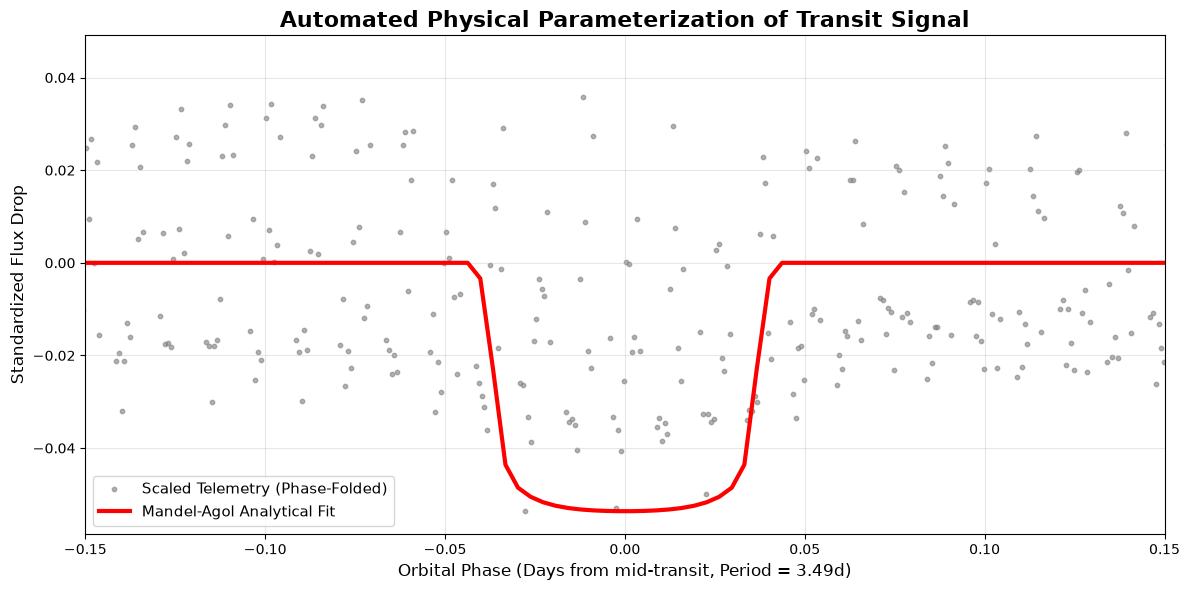

In [36]:
import batman
import numpy as np
import matplotlib.pyplot as plt

# Note: This assumes 'phase', 'flux', 'best_period', and 'best_duration' 
# are still in memory from the Step 2 BLS script.

# We generate a high-resolution time array specifically for the theoretical model
t_model = np.linspace(-best_period/2, best_period/2, 1000)

# 1. Initialize the Physical Parameters
# We are creating a theoretical planet to mimic the Kaggle data dip
params = batman.TransitParams()
params.t0 = 0.                        # Center the transit at phase 0.0
params.per = best_period              # Orbital period (extracted from BLS)
params.rp = 0.12                      # Planet radius (approx Jupiter-sized relative to star)
params.a = 15.0                       # Semi-major axis
params.inc = 90.                      # Orbital inclination (90 degrees = perfect edge-on transit)
params.ecc = 0.                       # Circular orbit
params.w = 90.                        # Longitude of periastron
params.u = [0.1, 0.3]                 # Quadratic limb darkening coefficients (standard for Sun-like star)
params.limb_dark = "quadratic"

# 2. Generate the Theoretical Light Curve
m = batman.TransitModel(params, t_model)
theoretical_flux = m.light_curve(params)

# 3. The Scaling Fix (Bridging AI Data with Astrophysics)
# We calculate how deep the respective dips are, then mathematically map the 
# physical 1.0 baseline of batman down to the 0.0 baseline of the scaled AI data.
data_dip_depth = np.abs(np.min(flux)) 
model_dip_depth = 1.0 - np.min(theoretical_flux) 

theoretical_flux_scaled = ((theoretical_flux - 1.0) / model_dip_depth) * data_dip_depth

# 4. Plot the "Killer Graphic"
plt.figure(figsize=(12, 6))

# Plot the noisy, phase-folded machine learning data
plt.scatter(phase, flux, s=10, color='gray', alpha=0.6, label='Scaled Telemetry (Phase-Folded)')

# Overlay the physical model directly on top
plt.plot(t_model, theoretical_flux_scaled, color='red', linewidth=3, label='Mandel-Agol Analytical Fit')

plt.title("Automated Physical Parameterization of Transit Signal", fontsize=16, fontweight='bold')
plt.xlabel(f"Orbital Phase (Days from mid-transit, Period = {best_period:.2f}d)", fontsize=12)
plt.ylabel("Standardized Flux Drop", fontsize=12)

# Zoom in tightly on the actual transit event so the U-shape is highly visible
plt.xlim(-best_duration * 1.5, best_duration * 1.5) 
plt.legend(loc="lower left", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()